In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("delays.csv")

In [3]:
df.head()

,trip_id,date,time,transport_type,route_id,origin_station,destination_station,scheduled_departure,scheduled_arrival,actual_departure_delay_min,...,wind_speed_kmh,precipitation_mm,event_type,event_attendance_est,traffic_congestion_index,holiday,peak_hour,weekday,season,delayed
0,T00000,2023-01-01,05:00:00,Tram,Route_15,Station_31,Station_6,05:02:00,05:55:00,12,...,46,13.0,NaN,500,81,0,1,6,Winter,0
1,T00001,2023-01-01,05:15:00,Metro,Route_12,Station_49,Station_32,05:16:00,05:55:00,15,...,11,11.4,NaN,0,53,0,0,6,Autumn,1
2,T00002,2023-01-01,05:30:00,Bus,Route_16,Station_29,Station_42,05:33:00,06:17:00,0,...,31,14.1,Sports,0,67,1,0,6,Autumn,0
3,T00003,2023-01-01,05:45:00,Tram,Route_19,Station_26,Station_18,05:49:00,06:08:00,15,...,41,6.4,NaN,500,84,0,0,6,Winter,1
4,T00004,2023-01-01,06:00:00,Tram,Route_8,Station_18,Station_15,06:00:00,06:35:00,-1,...,30,18.5,NaN,500,46,0,0,6,Spring,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   trip_id                     2000 non-null   object 
 1   date                        2000 non-null   object 
 2   time                        2000 non-null   object 
 3   transport_type              2000 non-null   object 
 4   route_id                    2000 non-null   object 
 5   origin_station              2000 non-null   object 
 6   destination_station         2000 non-null   object 
 7   scheduled_departure         2000 non-null   object 
 8   scheduled_arrival           2000 non-null   object 
 9   actual_departure_delay_min  2000 non-null   int64  
 10  actual_arrival_delay_min    2000 non-null   int64  
 11  weather_condition           2000 non-null   object 
 12  temperature_C               2000 non-null   float64
 13  humidity_percent            2000 

In [5]:
df["event_type"] = df["event_type"].fillna("No Event")

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   trip_id                     2000 non-null   object 
 1   date                        2000 non-null   object 
 2   time                        2000 non-null   object 
 3   transport_type              2000 non-null   object 
 4   route_id                    2000 non-null   object 
 5   origin_station              2000 non-null   object 
 6   destination_station         2000 non-null   object 
 7   scheduled_departure         2000 non-null   object 
 8   scheduled_arrival           2000 non-null   object 
 9   actual_departure_delay_min  2000 non-null   int64  
 10  actual_arrival_delay_min    2000 non-null   int64  
 11  weather_condition           2000 non-null   object 
 12  temperature_C               2000 non-null   float64
 13  humidity_percent            2000 

In [7]:
df["actual_arrival_delay_min"].describe()

count    2000.000000
mean       13.318000
std         9.289727
min        -3.000000
25%         5.000000
50%        13.000000
75%        21.000000
max        29.000000
Name: actual_arrival_delay_min, dtype: float64

In [8]:
df["arrival_cat"] = pd.cut(
    df["actual_arrival_delay_min"],
    bins=[-4, 0, 5, 13, 21, 30],
    labels=[1, 2, 3, 4, 5]
)

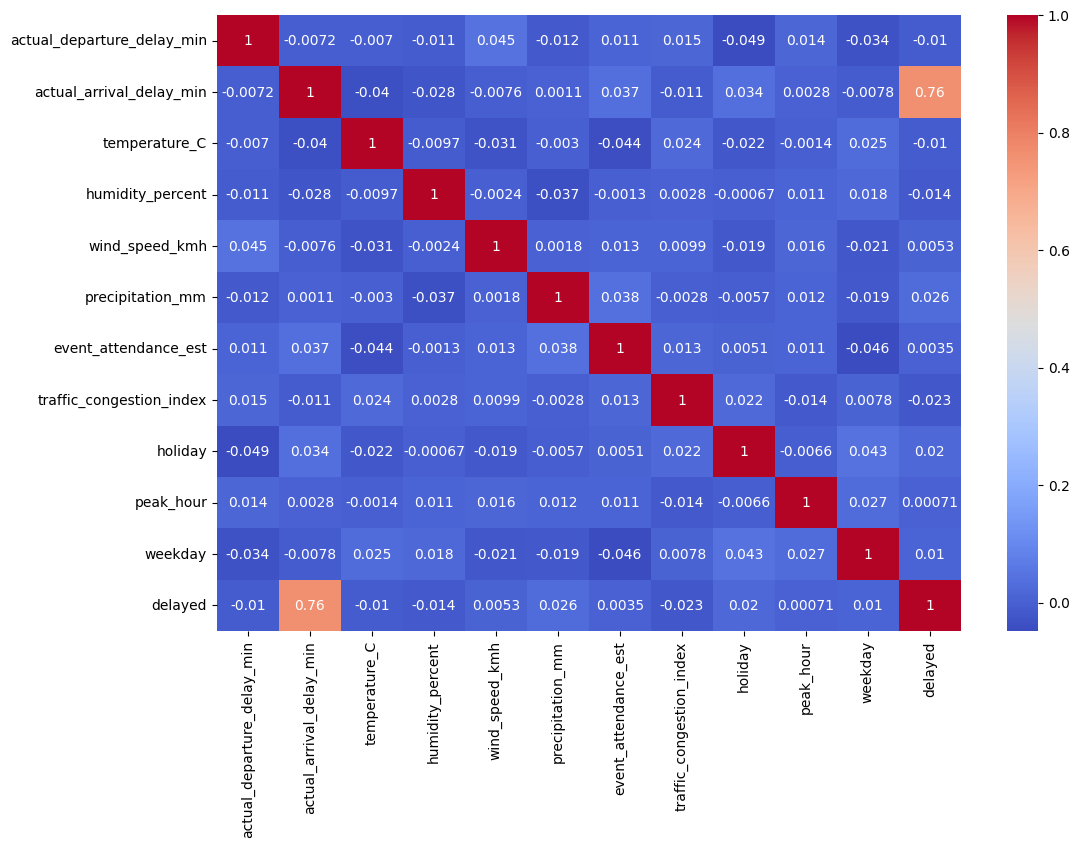

In [9]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()

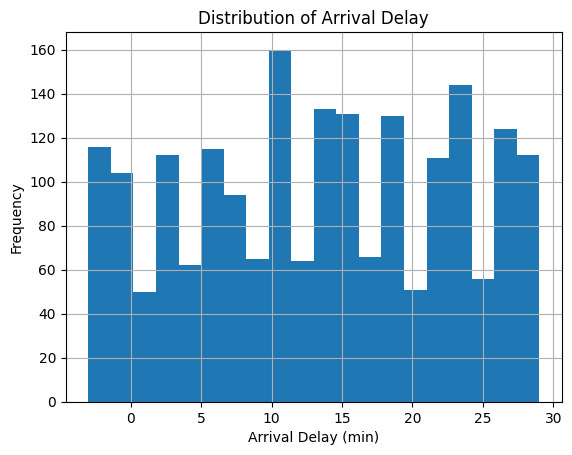

In [10]:
df["actual_arrival_delay_min"].hist(bins=20)
plt.xlabel("Arrival Delay (min)")
plt.ylabel("Frequency")
plt.title("Distribution of Arrival Delay")
plt.show()

In [11]:
#stratefied shuffle split
from sklearn.model_selection import StratifiedShuffleSplit
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_index, test_index in split.split(df, df['arrival_cat']):
    x_train = df.loc[train_index]
    x_test = df.loc[test_index]

In [12]:
y_train = x_train[['actual_arrival_delay_min']]
y_test = x_test[['actual_arrival_delay_min']]

In [13]:
#Removing the arrival_cat and not required columns
drop_attribs = [
    'actual_arrival_delay_min', # Dropping from X because it is our target y
    'trip_id', 
    'date', 
    'time', 
    'route_id', 
    'origin_station', 
    'destination_station', 
    'scheduled_departure', 
    'scheduled_arrival', 
    'actual_departure_delay_min', 
    'delayed',
    'arrival_cat'
]

for dataset in (x_train, x_test):
    dataset.drop(drop_attribs, axis=1, inplace=True)

In [14]:
df = x_train.copy()

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1600 entries, 78 to 159
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   transport_type            1600 non-null   object 
 1   weather_condition         1600 non-null   object 
 2   temperature_C             1600 non-null   float64
 3   humidity_percent          1600 non-null   int64  
 4   wind_speed_kmh            1600 non-null   int64  
 5   precipitation_mm          1600 non-null   float64
 6   event_type                1600 non-null   object 
 7   event_attendance_est      1600 non-null   int64  
 8   traffic_congestion_index  1600 non-null   int64  
 9   holiday                   1600 non-null   int64  
 10  peak_hour                 1600 non-null   int64  
 11  weekday                   1600 non-null   int64  
 12  season                    1600 non-null   object 
dtypes: float64(2), int64(7), object(4)
memory usage: 175.0+ KB


In [16]:
y_train

,actual_arrival_delay_min
78,18
1736,24
1776,-3
1068,11
1405,28
...,...
6,28
1581,6
362,14
1953,17


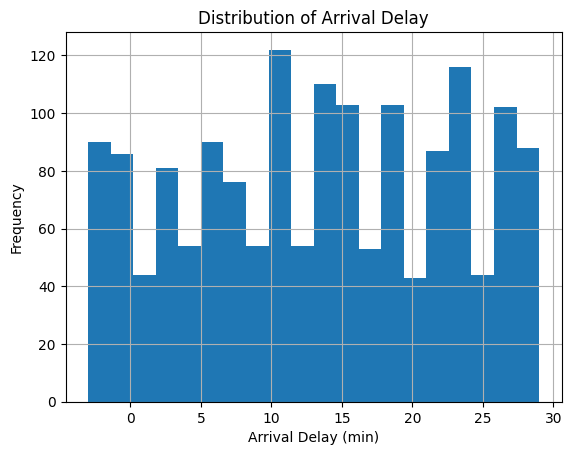

In [17]:
y_train["actual_arrival_delay_min"].hist(bins=20)
plt.xlabel("Arrival Delay (min)")
plt.ylabel("Frequency")
plt.title("Distribution of Arrival Delay")
plt.show()

In [18]:
y_test

,actual_arrival_delay_min
1006,2
852,6
1755,26
1037,11
1458,8
...,...
311,19
189,13
402,12
894,-2


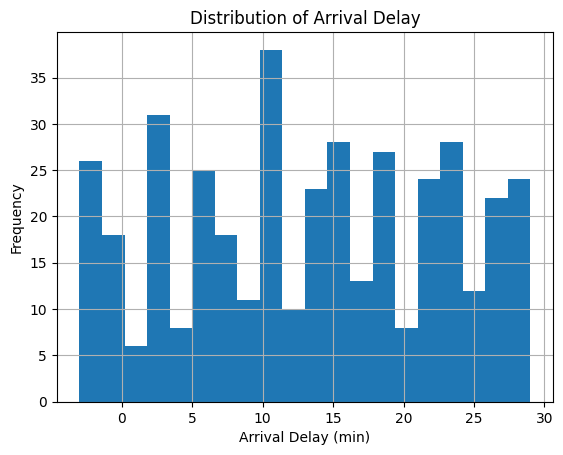

In [19]:
y_test["actual_arrival_delay_min"].hist(bins=20)
plt.xlabel("Arrival Delay (min)")
plt.ylabel("Frequency")
plt.title("Distribution of Arrival Delay")
plt.show()

In [20]:
df.head()

,transport_type,weather_condition,temperature_C,humidity_percent,wind_speed_kmh,precipitation_mm,event_type,event_attendance_est,traffic_congestion_index,holiday,peak_hour,weekday,season
78,Tram,Rain,18.5,47,35,13.3,No Event,0,7,0,1,0,Autumn
1736,Bus,Clear,14.4,84,46,12.6,Sports,0,98,0,1,3,Summer
1776,Train,Cloudy,24.6,40,10,9.3,No Event,10000,87,1,0,3,Autumn
1068,Bus,Storm,21.6,43,47,14.7,Parade,0,34,0,0,3,Winter
1405,Metro,Storm,22.1,53,18,18.2,No Event,0,40,0,1,6,Spring


In [21]:
delay_num = df.select_dtypes(include=(np.number))

In [22]:
delay_num

,temperature_C,humidity_percent,wind_speed_kmh,precipitation_mm,event_attendance_est,traffic_congestion_index,holiday,peak_hour,weekday
78,18.5,47,35,13.3,0,7,0,1,0
1736,14.4,84,46,12.6,0,98,0,1,3
1776,24.6,40,10,9.3,10000,87,1,0,3
1068,21.6,43,47,14.7,0,34,0,0,3
1405,22.1,53,18,18.2,0,40,0,1,6
...,...,...,...,...,...,...,...,...,...
6,3.6,61,16,6.4,0,22,1,1,6
1581,3.4,94,40,12.9,0,51,0,1,1
362,14.8,35,12,15.3,0,3,0,1,2
1953,2.5,42,22,7.9,50000,92,0,0,5


In [23]:
delay_cat = df.copy()

In [24]:
delay_cat

,transport_type,weather_condition,temperature_C,humidity_percent,wind_speed_kmh,precipitation_mm,event_type,event_attendance_est,traffic_congestion_index,holiday,peak_hour,weekday,season
78,Tram,Rain,18.5,47,35,13.3,No Event,0,7,0,1,0,Autumn
1736,Bus,Clear,14.4,84,46,12.6,Sports,0,98,0,1,3,Summer
1776,Train,Cloudy,24.6,40,10,9.3,No Event,10000,87,1,0,3,Autumn
1068,Bus,Storm,21.6,43,47,14.7,Parade,0,34,0,0,3,Winter
1405,Metro,Storm,22.1,53,18,18.2,No Event,0,40,0,1,6,Spring
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6,Bus,Storm,3.6,61,16,6.4,Parade,0,22,1,1,6,Spring
1581,Train,Rain,3.4,94,40,12.9,Concert,0,51,0,1,1,Spring
362,Bus,Fog,14.8,35,12,15.3,No Event,0,3,0,1,2,Autumn
1953,Metro,Fog,2.5,42,22,7.9,No Event,50000,92,0,0,5,Winter


In [25]:
drop_attribs = [
    "temperature_C",
    "humidity_percent",
    "wind_speed_kmh",
    "precipitation_mm",
    "event_attendance_est",
    "traffic_congestion_index",
    "holiday",
    "peak_hour",
    "weekday"
]

delay_cat.drop(drop_attribs, axis=1, inplace=True)

In [26]:
delay_cat

,transport_type,weather_condition,event_type,season
78,Tram,Rain,No Event,Autumn
1736,Bus,Clear,Sports,Summer
1776,Train,Cloudy,No Event,Autumn
1068,Bus,Storm,Parade,Winter
1405,Metro,Storm,No Event,Spring
...,...,...,...,...
6,Bus,Storm,Parade,Spring
1581,Train,Rain,Concert,Spring
362,Bus,Fog,No Event,Autumn
1953,Metro,Fog,No Event,Winter


In [27]:
from sklearn.preprocessing import OneHotEncoder

In [28]:
onehot_encoder = OneHotEncoder()

In [29]:
delay_cat = onehot_encoder.fit_transform(delay_cat)

In [30]:
onehot_encoder.categories_

[array(['Bus', 'Metro', 'Train', 'Tram'], dtype=object),
 array(['Clear', 'Cloudy', 'Fog', 'Rain', 'Snow', 'Storm'], dtype=object),
 array(['Concert', 'Festival', 'No Event', 'Parade', 'Protest', 'Sports'],
       dtype=object),
 array(['Autumn', 'Spring', 'Summer', 'Winter'], dtype=object)]

In [31]:
delay_cat.toarray()

array([[0., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 1., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       ...,
       [1., 0., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 1.],
       [0., 1., 0., ..., 0., 0., 0.]], shape=(1600, 20))

In [32]:
delay_cat =  pd.DataFrame(delay_cat.toarray(), columns=['Bus', 'Metro', 'Train', 'Tram', 'Clear', 'Cloudy', 'Fog', 'Rain', 'Snow', 'Storm', 'Concert', 'Festival', 'No Event', 'Parade', 'Protest', 'Sports', 'Autumn', 'Spring', 'Summer', 'Winter'], index=df.index)

In [33]:
delay_cat

,Bus,Metro,Train,Tram,Clear,Cloudy,Fog,Rain,Snow,Storm,Concert,Festival,No Event,Parade,Protest,Sports,Autumn,Spring,Summer,Winter
78,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1736,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1776,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1068,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
1405,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
1581,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
362,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1953,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [34]:
delay_cat = df.copy()

In [35]:
delay_cat

,transport_type,weather_condition,temperature_C,humidity_percent,wind_speed_kmh,precipitation_mm,event_type,event_attendance_est,traffic_congestion_index,holiday,peak_hour,weekday,season
78,Tram,Rain,18.5,47,35,13.3,No Event,0,7,0,1,0,Autumn
1736,Bus,Clear,14.4,84,46,12.6,Sports,0,98,0,1,3,Summer
1776,Train,Cloudy,24.6,40,10,9.3,No Event,10000,87,1,0,3,Autumn
1068,Bus,Storm,21.6,43,47,14.7,Parade,0,34,0,0,3,Winter
1405,Metro,Storm,22.1,53,18,18.2,No Event,0,40,0,1,6,Spring
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6,Bus,Storm,3.6,61,16,6.4,Parade,0,22,1,1,6,Spring
1581,Train,Rain,3.4,94,40,12.9,Concert,0,51,0,1,1,Spring
362,Bus,Fog,14.8,35,12,15.3,No Event,0,3,0,1,2,Autumn
1953,Metro,Fog,2.5,42,22,7.9,No Event,50000,92,0,0,5,Winter


In [36]:
drop_attribs = [
    "temperature_C",
    "humidity_percent",
    "wind_speed_kmh",
    "precipitation_mm",
    "event_attendance_est",
    "traffic_congestion_index",
    "holiday",
    "peak_hour",
    "weekday"
]

delay_cat.drop(drop_attribs, axis=1, inplace=True)

In [37]:
delay_cat = onehot_encoder.fit_transform(delay_cat)

In [38]:
delay_cat = pd.DataFrame(
    delay_cat.toarray(),
    columns=onehot_encoder.get_feature_names_out(),
    index=df.index
)

In [39]:
delay_cat.head()

,transport_type_Bus,transport_type_Metro,transport_type_Train,transport_type_Tram,weather_condition_Clear,weather_condition_Cloudy,weather_condition_Fog,weather_condition_Rain,weather_condition_Snow,weather_condition_Storm,event_type_Concert,event_type_Festival,event_type_No Event,event_type_Parade,event_type_Protest,event_type_Sports,season_Autumn,season_Spring,season_Summer,season_Winter
78,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1736,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1776,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1068,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
1405,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [40]:
from sklearn.preprocessing import StandardScaler

In [41]:
delay_num

,temperature_C,humidity_percent,wind_speed_kmh,precipitation_mm,event_attendance_est,traffic_congestion_index,holiday,peak_hour,weekday
78,18.5,47,35,13.3,0,7,0,1,0
1736,14.4,84,46,12.6,0,98,0,1,3
1776,24.6,40,10,9.3,10000,87,1,0,3
1068,21.6,43,47,14.7,0,34,0,0,3
1405,22.1,53,18,18.2,0,40,0,1,6
...,...,...,...,...,...,...,...,...,...
6,3.6,61,16,6.4,0,22,1,1,6
1581,3.4,94,40,12.9,0,51,0,1,1
362,14.8,35,12,15.3,0,3,0,1,2
1953,2.5,42,22,7.9,50000,92,0,0,5


In [42]:
from sklearn.preprocessing import StandardScaler

In [43]:
scaler = StandardScaler()

In [44]:
delay_num_scaled = scaler.fit_transform(delay_num)

In [45]:
delay_num_scaled

array([[ 0.31198026, -0.86836791,  0.33497809, ..., -0.32163376,
         1.60356745, -1.48403202],
       [-0.04573398,  0.95239359,  0.97282449, ..., -0.32163376,
         1.60356745,  0.01341463],
       [ 0.84418927, -1.2128363 , -1.11467284, ...,  3.10912635,
        -0.62360956,  0.01341463],
       ...,
       [-0.01083503, -1.45888515, -0.99870076, ..., -0.32163376,
         1.60356745, -0.48573426],
       [-1.08397778, -1.11441676, -0.41884039, ..., -0.32163376,
        -0.62360956,  1.01171239],
       [ 0.03278866, -0.13022135,  1.66865694, ..., -0.32163376,
        -0.62360956, -1.48403202]], shape=(1600, 9))

In [46]:
delay_num_scaled = pd.DataFrame(delay_num_scaled, columns=delay_num.columns, index=df.index)

In [47]:
delay_num_scaled

,temperature_C,humidity_percent,wind_speed_kmh,precipitation_mm,event_attendance_est,traffic_congestion_index,holiday,peak_hour,weekday
78,0.311980,-0.868368,0.334978,0.591981,-0.421522,-1.475282,-0.321634,1.603567,-1.484032
1736,-0.045734,0.952394,0.972824,0.471386,-0.421522,1.631294,-0.321634,1.603567,0.013415
1776,0.844189,-1.212836,-1.114673,-0.097133,0.234703,1.255773,3.109126,-0.623610,0.013415
1068,0.582447,-1.065207,1.030811,0.833171,-0.421522,-0.553551,-0.321634,-0.623610,0.013415
1405,0.626071,-0.573109,-0.650785,1.436146,-0.421522,-0.348722,-0.321634,1.603567,1.510861
...,...,...,...,...,...,...,...,...,...
6,-0.988006,-0.179431,-0.766757,-0.596740,-0.421522,-0.963209,3.109126,1.603567,1.510861
1581,-1.005455,1.444491,0.624908,0.523070,-0.421522,0.026798,-0.321634,1.603567,-0.984883
362,-0.010835,-1.458885,-0.998701,0.936538,-0.421522,-1.611835,-0.321634,1.603567,-0.485734
1953,-1.083978,-1.114417,-0.418840,-0.338323,2.859602,1.426464,-0.321634,-0.623610,1.011712
